In [1]:
class CrystalOrientation:
    def __init__(self, alpha, beta, gamma):
        """
        Initialize the orientation with Euler angles (radians).
        Precompute the rotation matrix for efficiency.
        """
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        # precompute rotation matrix
        self.rotation_matrix = (
            self._Rz(alpha) @ self._Rx(beta) @ self._Rz(gamma)
        )

    @staticmethod
    def _Rz(phi):
        """Internal: rotation around z-axis."""
        return np.array([
            [np.cos(phi), -np.sin(phi), 0],
            [np.sin(phi),  np.cos(phi), 0],
            [0, 0, 1]
        ])

    @staticmethod
    def _Rx(theta):
        """Internal: rotation around x-axis."""
        return np.array([
            [1, 0, 0],
            [0, np.cos(theta), -np.sin(theta)],
            [0, np.sin(theta),  np.cos(theta)]
        ])
    
class CrystalLattice:
    def __init__(self, material):
        assert material in ['diamond', 'silicon', 'germanium'], "material variable should be in ['diamond', 'silicon', 'germanium']"
        if material == 'diamond':
            lattice_constant = 3.57108e-10
            symbols = ['C', 'C']
            charges = [6.0, 6.0]
            atomic_masses = [12.0 * 1.66e-27, 12.0 * 1.66e-27]
        elif material == 'silicon':
            lattice_constant = 5.4685679e-10
            symbols = ['Si', 'Si']
            charges = [14.0, 14.0]
            atomic_masses = [28.0 * 1.66e-27, 28.0 * 1.66e-27]
        elif material == 'germanium':
            lattice_constant = 5.6575e-10
            symbols = ['Ge', 'Ge']
            charges = [32.0, 32.0]
            atomic_masses = [72.0 * 1.66e-27, 72.0 * 1.66e-27]
        else:
            raise ValueError('try another material')
            
        
        cell = lattice_constant / 2 * (np.ones((3, 3)) - np.eye(3))
    
        positions = np.array([np.array([0.0, 0.0, 0.0]), lattice_constant / 4 * np.ones(3)])
        scaled_positions = positions @ np.linalg.inv(cell)

        rec_lattice = 2 * np.pi * np.linalg.inv(cell).T

        # atomic_masses = phonopy_model.unitcell.masses * 1.66e-27
        self.lattice_constant = lattice_constant
        self.charges = charges
        self.symbols = symbols
        self.lattice = cell
        self.scaled_positions = scaled_positions
        self.positions = positions
        self.rec_lattice = rec_lattice
        self.atomic_masses_kg = atomic_masses

In [2]:
import gemmi

def atomic_form_factor(q, symbol):
    assert len(q) == 3
    """
    Compute atomic form factor for given q vector and element symbol.

    q: (3,1) vector
    symbol: string, e.g. 'C'
    """
    q_mag = np.linalg.norm(q * 1.0e-10)  # convert m^-1 to A^-1 and calculate the magnitude (scalar)

    # Retrieve Gaussian fit parameters from gemmi database for the element
    element_current = gemmi.Element(symbol).it92
    coefficients = element_current.get_coefs()  # Returns list of 9 coefficients: a1..a4, b1..b4, c

    a = np.array(coefficients[:4])    # (4,) array: a1 to a4
    b = np.array(coefficients[4:8])   # (4,) array: b1 to b4
    c = np.array(coefficients[8])     # scalar: c
    
    return c + sum(aa * np.exp(-bb * (q_mag / 4.0 / np.pi) ** 2) for (aa, bb) in zip(a, b))

In [3]:
class PhononBandStructure:
    def __init__(self, phonopy_model):
        self.phonopy_model = phonopy_model

    def load_bandstructure_from_mp(self, mp_id, api_key_path='./myAPI.txt'):
        from mp_api.client import MPRester
        with open('./myAPI.txt', 'r') as api_file: 
            API_KEY = api_file.readline()
        with MPRester(API_KEY) as mpr:
            self.phonon_data_mp = mpr.get_phonon_bandstructure_by_material_id(mp_id)
        
        
    def mp_VS_vasp_comparison(self):
        """
        Compare phonon bandstructure from VASP (phonopy_model)
        with Materials Project data (phonon_data_mp) by plotting.
        """

        if self.phonon_data_mp is None:
            raise RuntimeError("MP data not loaded. Call load_bandstructure_from_mp() first.")

        # extract q-points from MP data
        qpoints = self.phonon_data_mp.qpoints
        # run phonopy calculation at the same q-points
        self.phonopy_model.run_qpoints(qpoints, with_eigenvectors=True)
        phonon_data_vasp = self.phonopy_model.get_qpoints_dict()

        # compute scaling factor (should be close to 1)
        scaling_factor = np.array(self.phonon_data_mp.frequencies).max() / phonon_data_vasp['frequencies'].max()
        print(f'{scaling_factor = }')

        colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b3", "#ccb974", "#64b5cd"]
        plt.figure(figsize=(8, 5))
        plt.grid(True)
        plt.title('Phonon bandstructure comparison (VASP VS MP)', fontsize='large')
        n_branches = phonon_data_vasp['frequencies'].shape[1]
        for branch_num in range(n_branches):
            plt.plot(phonon_data_vasp['frequencies'][:, branch_num] * scaling_factor, 
                     label=f'VASP (#{branch_num + 1})', linestyle='-', color=colors[branch_num % len(colors)]
                     )
            plt.plot(np.array(self.phonon_data_mp.frequencies)[branch_num, :], 
                     label=f'MP (#{branch_num + 1})', linestyle='-.', color=colors[branch_num % len(colors)]
                     )

        plt.legend()
        plt.xlabel('distance along path', fontsize='large')
        plt.ylabel('frequency (THz)', fontsize='large')

        # add high-symmetry labels
        index_label_dict = {}
        for q_idx, q_vec in enumerate(self.phonon_data_mp.qpoints):
            for label, q_label_vec in self.phonon_data_mp.labels_dict.items():
                if np.isclose(q_vec, q_label_vec, atol=1.0e-5).all() and (q_idx - 1 not in index_label_dict):
                    index_label_dict[q_idx] = label if label != '\Gamma' else 'Г'
                    print(f'{index_label_dict[q_idx]}: {q_vec}')
                    break

        xticks_positions = sorted(index_label_dict.keys())
        plt.xticks(xticks_positions, [index_label_dict[pos] for pos in xticks_positions])
        plt.show()

    def forget_mp_data(self):
        self.phonon_data_mp = None
    
    def get_frequency(self, q_vec, branch_num):
        """
        Return frequency of a specific branch at q_vec, in THz (!!! i.e. nu [THz], not omega !!!)
        """
        q_vec = np.array(q_vec)
        self.phonopy_model.run_qpoints([q_vec])
        freqs = self.phonopy_model.qpoints.frequencies[0]
        return freqs[branch_num]

    
    def get_frequency_and_eigvec(self, q_vec, branch_num):
        """
        Return (frequency, eigenvector) of a specific branch at q_vec.
        """
        q_vec = np.array(q_vec)
        self.phonopy_model.run_qpoints([q_vec], with_eigenvectors=True)
        freqs = self.phonopy_model.qpoints.frequencies[0]
        eigvecs = self.phonopy_model.qpoints.eigenvectors[0]
        return freqs[branch_num], eigvecs[:, branch_num]

    # ------------------------------
    # All branches frequency
    # ------------------------------
    def get_frequencies(self, q_vec):
        """
        Return all frequencies at q_vec.
        """
        q_vec = np.array(q_vec)
        self.phonopy_model.run_qpoints([q_vec])
        freqs = self.phonopy_model.qpoints.frequencies[0]
        return freqs

    # ------------------------------
    # All branches frequency + eigenvectors
    # ------------------------------
    def get_frequencies_and_eigvecs(self, q_vec):
        """
        Return (frequencies array, eigenvectors matrix) at q_vec.
        """
        q_vec = np.array(q_vec)
        self.phonopy_model.run_qpoints([q_vec], with_eigenvectors=True)
        freqs = self.phonopy_model.qpoints.frequencies[0]
        eigvecs = self.phonopy_model.qpoints.eigenvectors[0]
        # here, the signature of phonopy_model.qpoints.eigenvectors is:
        # phonopy_model.qpoints.eigenvectors[qpoint_index, component_index, branch_index]
        # where:
        #     qpoint_index: 0.. len(qpoints)
        #     component_index: 0.. 3 * number_of_atoms_in_unit_cell 
        #          (0, 1, 2 - for the first atom in the cell,
        #           3, 4, 5 - for the second one, and so on)
        #     branch_index: 0.. 3 * number_of_atoms_in_unit_cell 
        # important: the components are given in the CARTESIAN coordinates, not in the basis of RLVs
        return freqs, eigvecs


    def check_eigvecs_symmetry(self, rec_lattice):
        qpoint = np.array([0.00239, 0.00731, 0.004321])   # the phonon wavevector should be close to the Gamma-point        
        _, eigvec = self.get_frequencies_and_eigvecs(qpoint)
        print(f'{eigvec.shape = }')
        
        b1, b2, b3 = rec_lattice[:]

        for branch_num in range(6):
            for atom_num in range(2):
                e_vec = eigvec[3 * atom_num: 3 * atom_num + 3, branch_num]
                q_cart = qpoint[0] * b1 + qpoint[1] * b2 + qpoint[2] * b3
                # print(f'{e_vec = }')
                # print(f'{q_cart = }')
                # print(f'{q_cart = }')
                print(f'branch #{branch_num + 1}, atom #{atom_num + 1}')
                print('cos(angle(q, e_j(q))) = {:8.5f}'.format(np.abs(q_cart @ e_vec) / np.linalg.norm(q_cart) / np.linalg.norm(e_vec)))
                print()
        

    def get_phonon_dos(self, mesh):
        self.phonopy_model.run_mesh(mesh)
        self.phonopy_model.run_total_dos()

        dos_dict = self.phonopy_model.get_total_dos_dict()
        frequencies = dos_dict["frequency_points"]
        dos_arr = dos_dict["total_dos"]

        omega_arr = frequencies * 2.0 * np.pi * 1.0e+12   # from THz to s^-1
        dos_arr /= np.average(dos_arr) * (omega_arr[-1] - omega_arr[0])
        return omega_arr, dos_arr
    
def bose_einstein_distr(omega, temperature):
    n = 1.0 / (np.exp(hbar * omega / kB / temperature) - 1)
    return n

def get_dwf_constant(omega_arr, dos_arr, atom_mass, temperature):
    # calculates B_a = hbar / (4 * M_a) * int d omega g(omega) * (2 * n + 1) / omega,
    # that is related with the Debye-Waller factor as
    # W_a(q) = B_a * |q|^2
    integrand = dos_arr * (2.0 * bose_einstein_distr(omega=omega_arr, temperature=temperature) + 1.0) / omega_arr
    integral = np.average(integrand) * (omega_arr[-1] - omega_arr[0])
    B_a = hbar / 4.0 / atom_mass * integral
    return B_a

In [4]:
def reduce_to_1stBZ_withRotation(q, crystal_orientation, crystal_lattice):
    b1, b2, b3 = crystal_lattice.rec_lattice[:]

    # Solve in reciprocal lattice basis (safer with transpose)
    coeffs = np.linalg.solve(np.array([b1, b2, b3]).T, crystal_orientation.rotation_matrix.T @ q)
    ll, mm, nn = np.round(coeffs).astype(int)

    min_dist, argmin = float('+inf'), None

    for (l, m, n) in product([ll, ll - 1, ll + 1],
                             [mm, mm - 1, mm + 1],
                             [nn, nn - 1, nn + 1]):
        BZ_center = l * b1 + m * b2 + n * b3
        dist = np.linalg.norm(q - crystal_orientation.rotation_matrix @ BZ_center)
        if dist < min_dist:
            min_dist = dist
            argmin = (l, m, n)

    (l, m, n) = argmin

    q_BZ = np.linalg.solve(
        np.array([b1, b2, b3]).T,
        crystal_orientation.rotation_matrix.T @ q - (l * b1 + m * b2 + n * b3)
    )

    return q_BZ, (l, m, n)

def photon_momentum_loss(theta_val, phi_val, channel, branch_num, phonon_band_structure, crystal_orientation, crystal_lattice):
    assert channel.lower() in ['s', 'as']
    
    q_seed = omega_in / c * np.array([
        -np.sin(theta_val) * np.cos(phi_val),
        -np.sin(theta_val) * np.sin(phi_val),
        1.0 - np.cos(theta_val),
    ])

    if channel.lower() == 's':
        q_BZ, _ = reduce_to_1stBZ_withRotation(q=q_seed, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice)
    elif channel.lower() == 'as':
        q_BZ, _ = reduce_to_1stBZ_withRotation(q=-q_seed, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice)
    
    omega_phonon = phonon_band_structure.get_frequency(q_vec=q_BZ, branch_num=branch_num) * 2.0 * np.pi * 1.0e+12

    if channel.lower() == 's':
        q = omega_in / c * np.array([0.0, 0.0, 1.0]) - (omega_in - omega_phonon) / c * np.array([
            np.sin(theta_val) * np.cos(phi_val),
            np.sin(theta_val) * np.sin(phi_val),
            np.cos(theta_val),
        ])
    elif channel.lower() == 'as':
        q = omega_in / c * np.array([0.0, 0.0, 1.0]) - (omega_in + omega_phonon) / c * np.array([
            np.sin(theta_val) * np.cos(phi_val),
            np.sin(theta_val) * np.sin(phi_val),
            np.cos(theta_val),
        ])
    else:
        raise ValueError('incorrect value of the channel parameter')
    return q

In [5]:
def is_close_to_bz_border(q_BZ, crystal_lattice, eps=1.0e-3):
    # q_BZ is in reciprocal lattice basis!!!
    qqx, qqy, qqz = np.abs(q_BZ @ crystal_lattice.rec_lattice)
    
    if np.isclose(qqx + qqy + qqz, 3.0 * np.pi / crystal_lattice.lattice_constant, rtol=eps):
        return True
    
    if any(np.isclose(qq_, 2.0 * np.pi / crystal_lattice.lattice_constant, rtol=eps) for qq_ in [qqx, qqy, qqz]):
        return True
    return False

def get_bz_border(theta_grid, phi_grid, crystal_orientation, crystal_lattice, phonon_band_structure, eps=1.0e-3):
    bz_border = {
        'theta': [], 
        'phi': [], 
        'qx': [], 
        'qy': [], 
        'qz': [],
    }
    for (theta_ind, theta) in enumerate(theta_grid):
        for (phi_ind, phi) in enumerate(phi_grid):
            # q = photon_momentum_loss(theta, phi, channel='s', branch_num=5, 
            #                          crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)    
            q = omega_in / c * np.array([
                -np.sin(theta) * np.cos(phi),
                -np.sin(theta) * np.sin(phi),
                1.0 - np.cos(theta),
            ])
            q_BZ, (l, m, n) = reduce_to_1stBZ_withRotation(q, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice)
    

            if is_close_to_bz_border(q_BZ, crystal_lattice, eps=eps):
                bz_border['theta'].append(theta)
                bz_border['phi'].append(phi)
                bz_border['qx'].append(q[0])
                bz_border['qy'].append(q[1])
                bz_border['qz'].append(q[2])
    for key in bz_border.keys():
        bz_border[key] = np.array(bz_border[key])
    return bz_border

In [6]:
def get_sas_data(theta_grid, phi_grid, crystal_orientation, crystal_lattice, phonon_band_structure, branch_num):
    data_s = {'theta_ind': [], 'phi_ind': [], 'q_BZ': [], 'lmn': [], 'q_s': []}
    data_as = {'theta_ind': [], 'phi_ind': [], 'q_BZ': [], 'lmn': [], 'q_as': []}

    for (theta_ind, theta) in enumerate(theta_grid):
        for (phi_ind, phi) in enumerate(phi_grid):
            q_s = photon_momentum_loss(theta, phi, channel='s', branch_num=branch_num, 
                                       crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)
            q_as = photon_momentum_loss(theta, phi, channel='as', branch_num=branch_num, 
                                        crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)
        
            q_BZ_s, (ls, ms, ns) = reduce_to_1stBZ_withRotation(q_s, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice)
            q_BZ_as, (las, mas, nas) = reduce_to_1stBZ_withRotation(-q_as, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice)

            data_s['theta_ind'].append(theta_ind)
            data_s['phi_ind'].append(phi_ind)
            data_s['q_BZ'].append(q_BZ_s)
            data_s['lmn'].append((ls, ms, ns))
            data_s['q_s'].append(q_s)

            data_as['theta_ind'].append(theta_ind)
            data_as['phi_ind'].append(phi_ind)
            data_as['q_BZ'].append(q_BZ_as)
            data_as['lmn'].append((las, mas, nas))
            data_as['q_as'].append(q_as)

    data_s['theta_ind'] = np.array(data_s['theta_ind'], dtype=int)
    data_s['phi_ind']   = np.array(data_s['phi_ind'], dtype=int)
    data_s['q_BZ']      = np.array(data_s['q_BZ'], dtype=float)
    data_s['lmn']       = np.array(data_s['lmn'], dtype=int)
    data_s['q_s']       = np.array(data_s['q_s'], dtype=float)

    data_as['theta_ind'] = np.array(data_as['theta_ind'], dtype=int)
    data_as['phi_ind']   = np.array(data_as['phi_ind'], dtype=int)
    data_as['q_BZ']      = np.array(data_as['q_BZ'], dtype=float)
    data_as['lmn']       = np.array(data_as['lmn'], dtype=int)
    data_as['q_as']      = np.array(data_as['q_as'], dtype=float)

    return data_s, data_as

In [7]:
def find_pairs(data_s, data_as, N_best, k_neighbors):
    # ============================================
    # Keep only points with (l, m, n) != (0, 0, 0)
    # ============================================
    mask_s = np.any(data_s['lmn'] != 0, axis=1)
    mask_as = np.any(data_as['lmn'] != 0, axis=1)

    ######
    mask_s = np.array([True for _ in data_s['lmn']])
    mask_as = np.array([True for _ in data_as['lmn']])
    mask_s = np.array([theta_grid[theta_ind] > 2.5e-2 for theta_ind in data_s['theta_ind']])
    mask_as = np.array([theta_grid[theta_ind] > 2.5e-2 for theta_ind in data_as['theta_ind']])
    ######

    q_BZ_s_filtered = data_s['q_BZ'][mask_s]
    q_BZ_as_filtered = data_as['q_BZ'][mask_as]
    q_s_filtered = data_s['q_s'][mask_s]
    q_as_filtered = data_as['q_as'][mask_as]
    # q_s_nonzero = data_s['q_BZ'][mask_s]
    # q_as_nonzero = data_as['q_BZ'][mask_as]

    theta_ind_s = data_s['theta_ind'][mask_s]
    phi_ind_s   = data_s['phi_ind'][mask_s]
    lmn_s       = data_s['lmn'][mask_s]

    theta_ind_as = data_as['theta_ind'][mask_as]
    phi_ind_as   = data_as['phi_ind'][mask_as]
    lmn_as       = data_as['lmn'][mask_as]

    # ============================================
    # Search for matching q_BZ using KDTree
    # ============================================
    tree_as = cKDTree(q_BZ_as_filtered)

    k = min(k_neighbors, len(q_BZ_as_filtered))
    distances, nearest_idx = tree_as.query(q_BZ_s_filtered, k=k)

    # scipy returns 1D arrays when k=1, but 2D arrays when k>1
    # make both cases uniform
    if k == 1:
        distances = distances[:, np.newaxis]
        nearest_idx = nearest_idx[:, np.newaxis]

    # --------------------------------------------
    # Build a global candidate list
    # Each Stokes point contributes its k nearest
    # anti-Stokes candidates
    # --------------------------------------------
    candidates = []

    for i_s in range(len(q_BZ_s_filtered)):
        for j in range(k):
            i_as = nearest_idx[i_s, j]
            dist = distances[i_s, j]

            candidates.append({
                'distance': dist,
                'stokes_idx': i_s,
                'antistokes_idx': i_as,
                'neighbor_rank': j + 1,   # 1st nearest, 2nd nearest, ...
                'q_BZ_s': q_BZ_s_filtered[i_s],
                'q_BZ_as': q_BZ_as_filtered[i_as],
                'q_s': q_s_filtered[i_s],
                'q_as': q_as_filtered[i_as],
                'theta_s': theta_grid[theta_ind_s[i_s]],
                'phi_s': phi_grid[phi_ind_s[i_s]],
                'theta_as': theta_grid[theta_ind_as[i_as]],
                'phi_as': phi_grid[phi_ind_as[i_as]],
                'lmn_s': tuple(lmn_s[i_s]),
                'lmn_as': tuple(lmn_as[i_as]),
            })
            # print(f'{data_s["q_s"][mask_s][i_s] = }')
            

    # --------------------------------------------
    # Sort all candidates globally by mismatch
    # --------------------------------------------
    candidates.sort(key=lambda item: item['distance'])

    # --------------------------------------------
    # Collect best unique matches
    # Prevent reuse of the same Stokes point
    # and the same anti-Stokes point
    # --------------------------------------------
    matches = []
    used_s = set()
    used_as = set()

    for cand in candidates:
        i_s = cand['stokes_idx']
        i_as = cand['antistokes_idx']

        if i_s in used_s or i_as in used_as:
            continue

        matches.append(cand)
        used_s.add(i_s)
        used_as.add(i_as)
    
    best_matches = matches[:N_best]
    return best_matches

In [8]:
def safe_ratio(Ni, delta):
    small = np.abs(delta) < 1e-10
    out = np.empty_like(delta)
    out[small] = Ni
    out[~small] = np.sin(Ni * delta[~small] / 2) / np.sin(delta[~small] / 2)
    return out

def get_phase_integral(q, N, T_int, channel, omega_phonon, crystal_orientation, crystal_lattice, rng=20.0, grid_size=201):
    """
    let q = k_in - k_out
    integrate over k_out the following expression:
    \int d^3 k_out (sin(N_1 * q \cdot a_1 / 2) / (q \cdot a_1 / 2) * 
                    sin(N_2 * q \cdot a_2 / 2) / (q \cdot a_2 / 2) * 
                    sin(N_3 * q \cdot a_3 / 2) / (q \cdot a_3 / 2) * 
                    sin(T_int * (c * |k_in| - c * |k_out| -+ omega_phonon) / 2) / ((c * |k_in| - c * |k_out| -+ omega_phonon) / 2))^2
    (- for Stokes, + for anti-Stokes)
    """
    a = crystal_lattice.lattice

    k0 = k_in - q   # "central" k_out momentum 
    # print(f'{a = }')
    # print(f'{np.linalg.norm(a, axis=1).max() = }')
    dk = rng * np.pi / N.max() / np.linalg.norm(a, axis=1).max()

    kx = k0[0] + np.linspace(-dk, dk, grid_size)
    ky = k0[1] + np.linspace(-dk, dk, grid_size)
    kz = k0[2] + np.linspace(-dk, dk, grid_size)

    dx = kx[1] - kx[0]
    dy = ky[1] - ky[0]
    dz = kz[1] - kz[0]

    # Mesh
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K_out = np.stack([KX, KY, KZ], axis=-1)

    # Spatial mismatch
    delta_k = k_in - K_out - q

    # print(f'correct this part - I forgot to rotate the lattice vectors !!!')
    d1 = np.tensordot(delta_k, crystal_orientation.rotation_matrix @ a[0], axes=([3], [0]))
    d2 = np.tensordot(delta_k, crystal_orientation.rotation_matrix @ a[1], axes=([3], [0]))
    d3 = np.tensordot(delta_k, crystal_orientation.rotation_matrix @ a[2], axes=([3], [0]))

    spatial = (safe_ratio(N[0], d1) * safe_ratio(N[1], d2) * safe_ratio(N[2], d3))
    # Frequency mismatch
    k_out_norm = np.linalg.norm(K_out, axis=3)
    k_in_norm = np.linalg.norm(k_in)

    if channel == "s":
        omega_diff = c * (k_in_norm - k_out_norm) - omega_phonon
    elif channel == "as":
        omega_diff = c * (k_in_norm - k_out_norm) + omega_phonon
    else:
        raise ValueError('incorrect value of the channel parameter')
    
    small = np.abs(omega_diff) < 1e-12
    time = np.empty_like(omega_diff)
    time[small] = T_int
    time[~small] = np.sin(T_int * omega_diff[~small] / 2) / (omega_diff[~small] / 2)

    integrand = (spatial * time) ** 2
    phase_integral = np.sum(integrand) * dx * dy * dz 
    
    # ???
    phase_integral /= T_int ** 2
    # ???
    
    return phase_integral

def get_interaction_constant(q, branch_num, channel, crystal_orientation, crystal_lattice, phonon_band_structure, B_arr):
    # prefactor calculation
    k_out = k_in - q
    prefactor = np.sqrt(photon_number_density) / (2.0 * np.pi) ** 1.5
    prefactor *= 2.0 * np.pi * hbar * c * r_e / np.sqrt(np.linalg.norm(k_in) * np.linalg.norm(k_out))

    # q_BZ calculation (would be necessary both for atomic sum and for phase integral)
    if channel.lower() == 's':
        q_BZ, lmn = reduce_to_1stBZ_withRotation(q, crystal_orientation, crystal_lattice)
    elif channel.lower() == 'as':
        q_BZ, lmn = reduce_to_1stBZ_withRotation(-q, crystal_orientation, crystal_lattice)
    
    freq_phonon, eigvec = phonon_band_structure.get_frequency_and_eigvec(q_BZ, branch_num)
    omega_phonon = freq_phonon * 2.0 * np.pi * 1.0e+12
    atomic_sum = 0.0
    for atom in range(len(crystal_lattice.symbols)):
        atomic_ff = atomic_form_factor(q, crystal_lattice.symbols[atom])
        # dwf = 0.0    fix later
        dwf = np.exp(-B_arr[atom] * np.linalg.norm(q) ** 2)
        phase_factor = np.exp(-1.0j * q @ (crystal_orientation.rotation_matrix @ crystal_lattice.positions[atom]))
        
        atomic_mass = crystal_lattice.atomic_masses_kg[atom]

        to_add = atomic_ff * np.exp(-dwf) * phase_factor 
        to_add *= np.sqrt(hbar / 2.0 / prim_cell_number / atomic_mass / omega_phonon)
        to_add *= q @ (crystal_orientation.rotation_matrix @ eigvec[3*atom: 3*atom+3])
        atomic_sum += to_add

    phase_integral = get_phase_integral(q, N, T_int, channel, omega_phonon, crystal_orientation, crystal_lattice)

    print(f'{prefactor = }')
    print(f'{atomic_sum = }')
    print(f'{phase_integral ** 0.5 = }')
    g_q0 = prefactor * atomic_sum * phase_integral ** 0.5
    return g_q0

phonopy model loaded
N = array([12930, 12930, 12930])


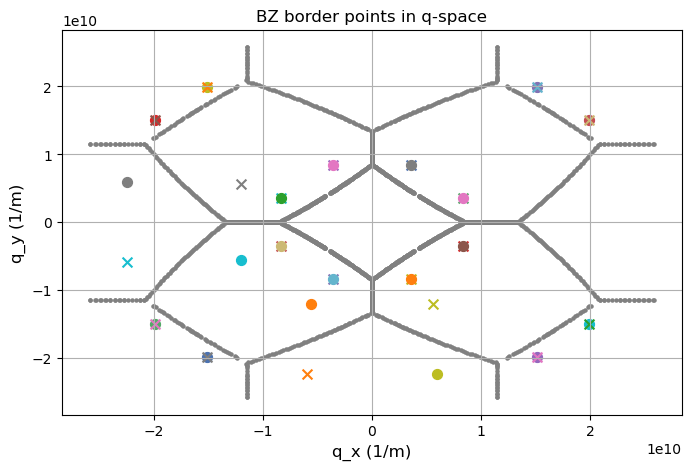

In [24]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from itertools import product
from phonopy import load
import qutip as qt


hbar = 1.05457e-34  # reduced Planck constant
c = 299_792_458.0   # speed of light
r_e = 2.81794e-15   # classical electron radius
kB = 1.38065e-23    # Boltzmann constant

pulse_duration = 30.0e-15    # 30 fs
photon_number = 1.0e+12      # number of photons in the pulse
pulse_width = 10.0e-6        # 10 microns - in transversave direction

E_in_ev = 10_000.0
omega_in = E_in_ev * 1.60218e-19 / hbar
k_in = np.array([0, 0, omega_in / c])
temperature = 300.0

# either this
# material = 'diamond'
# yaml_filename = '../VASP_data/diamond/phonopy_disp.yaml'
# fc_filename = '../VASP_data/diamond/FORCE_CONSTANTS'

# or this
material = 'silicon'
yaml_filename = '../VASP_data/silicon/phonopy_disp.yaml'
fc_filename = '../VASP_data/silicon/FORCE_CONSTANTS'

crystal_lattice = CrystalLattice(material=material)
phonopy_model = load(phonopy_yaml=yaml_filename, 
                     force_constants_filename=fc_filename, 
                     calculator='vasp'
                    )
print('phonopy model loaded')
phonon_band_structure = PhononBandStructure(phonopy_model=phonopy_model)

alpha, beta, gamma = 0.0, 0.0, 0.0
crystal_orientation = CrystalOrientation(alpha, beta, gamma)


# cubic crystal 10 um x 10 um x 10 um
# Lx = 10.0e-6    
# Ly = 10.0e-6    
# Lz = 10.0e-6  
# crystal_volume = Lx * Ly * Lz

# dimensions along the lattice vectors a1, a2, a3
# L1, L2, L3 = 10.0e-6, 10.0e-6, 10.0e-6
L1, L2, L3 = np.array([1, 1, 1], dtype=float) * 10.0e-6 / np.sqrt(2.0)      # then, the crystal cross section would be 10 um x 10 um - limitation due to the pulse width
crystal_volume = L1 * L2 * L3 / np.sqrt(2.0)   # valid only for FCC lattice, fix later for other lattices

prim_cell_volume = crystal_lattice.lattice_constant ** 3 / 4.0
prim_cell_number = int((crystal_volume / prim_cell_volume))

N = np.array([L1, L2, L3]) / crystal_lattice.lattice_constant
N = N.astype(int)
print(f'{N = }')


photon_number_density = photon_number / (pulse_width ** 2 * (c * pulse_duration))
T_int = min(pulse_duration, (L1 + L2) / np.sqrt(2.0) / c)   # for this specific crystal shape and orientation, fix later for other cases

### DOS and DWF coefficient precalculation
mesh = [50, 50, 50]
omega_arr, dos_arr = phonon_band_structure.get_phonon_dos(mesh)
B_arr = [get_dwf_constant(omega_arr, dos_arr, atom_mass=crystal_lattice.atomic_masses_kg[atom], temperature=temperature) for atom in range(len(crystal_lattice.symbols))]


theta_grid = np.pi - np.linspace(0.0, 0.6, 801)
phi_grid = np.linspace(0.0, 2.0 * np.pi, 901)

bz_border = get_bz_border(theta_grid, phi_grid, crystal_orientation, crystal_lattice, phonon_band_structure, eps=1.0e-3)

branch_num = 5
data_s, data_as = get_sas_data(theta_grid, phi_grid, crystal_orientation, crystal_lattice, phonon_band_structure, branch_num=branch_num)

N_best = 20
k_neighbors = 5
best_matches = find_pairs(data_s, data_as, N_best=N_best, k_neighbors=k_neighbors)

colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b3", "#ccb974",
          "#64b5cd", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
          "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
          "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#ff7f0e",
]

plt.figure(figsize=(8, 5))
plt.scatter(bz_border['qx'], bz_border['qy'], s=5, color='grey')
for (match_ind, match) in enumerate(best_matches[:]):
    plt.scatter(match['q_s'][0], match['q_s'][1], s=50, color=colors[match_ind], marker='o', label='Stokes')
    plt.scatter(match['q_as'][0], match['q_as'][1], s=50, color=colors[match_ind], marker='x', label='anti-Stokes')
plt.xlabel('q_x (1/m)', fontsize='large')
plt.ylabel('q_y (1/m)', fontsize='large')
plt.title('BZ border points in q-space', fontsize='large')
plt.grid(True)
plt.show()

enhancement_factor_s = 50.506621110891366
enhancement_factor_as = 50.506621110891366
prefactor = 2.3385842260334286e-38
atomic_sum = (-7.277244890102589e-08-1.298961553319721e-07j)
phase_integral ** 0.5 = 1.973892539309268e+21
prefactor = 2.3385706303465926e-38
atomic_sum = (-1.462159236619437e-07-1.0076017904054467e-07j)
phase_integral ** 0.5 = 2.1624728807422852e+21
g_s_eff * T_int / hbar = 0.09875115144252669
g_as_eff * T_int / hbar = 0.1290235776815063
nS = 0.010917833581953449
naS = 0.002000148817333093
nrf = 0.9999129106081218

enhancement_factor_s = 50.506621110891366
enhancement_factor_as = 50.506621110891366
prefactor = 2.3385842260334286e-38
atomic_sum = (-1.4383114588312492e-07-3.848950458277476e-08j)
phase_integral ** 0.5 = 1.973892539309268e+21
prefactor = 2.3385706303465926e-38
atomic_sum = (-1.7420098483904652e-07+3.443438533942989e-08j)
phase_integral ** 0.5 = 2.1624728807422272e+21
g_s_eff * T_int / hbar = 0.09875115144252662
g_as_eff * T_int / hbar = 0.129023577681503

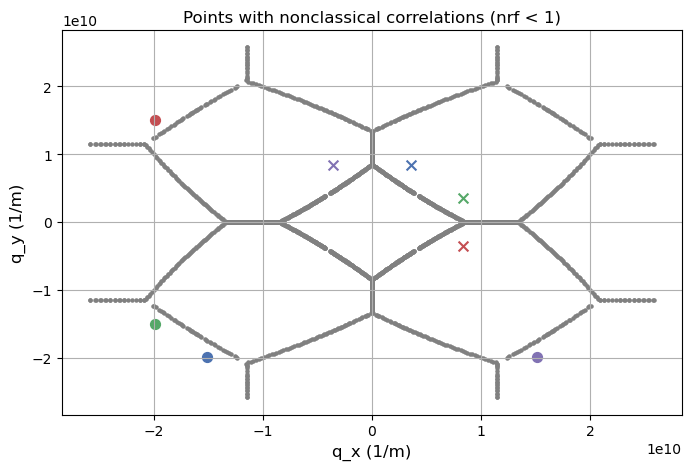

[0.9999129106081218,
 0.9999129106081225,
 0.9988215983844061,
 0.9988215983844063]

In [ ]:
def get_enhancement_factor(pixel_area, sample_pixel_distance, photon_momentum, crystal_volume):
    Delta_Omega = pixel_area / sample_pixel_distance ** 2
    delta_q_par = 2.0 * np.pi / crystal_volume ** 0.333
    delta_V_q = photon_momentum ** 2 * Delta_Omega * delta_q_par

    qpoints_density = crystal_volume / (2.0 * np.pi) ** 3
    mode_number = delta_V_q * qpoints_density
    enhacement_factor = np.sqrt(mode_number)
    return enhacement_factor


def get_photon_numbers_and_nrf(g_S, g_aS, nbar, t_final, photon_cutoff, phonon_cutoff):
    aS_dag = qt.create(photon_cutoff)
    aS = qt.destroy(photon_cutoff)

    aaS_dag = qt.create(photon_cutoff)
    aaS = qt.destroy(photon_cutoff)

    b_dag = qt.create(phonon_cutoff)
    b = qt.destroy(phonon_cutoff)

    Iph = qt.qeye(photon_cutoff)
    Iphn = qt.qeye(phonon_cutoff)

    rho_init = qt.tensor(
        qt.fock_dm(photon_cutoff, 0),
        qt.fock_dm(photon_cutoff, 0),
        qt.thermal_dm(phonon_cutoff, nbar)
    )

    H = (
        g_S * qt.tensor(aS_dag, Iph, b_dag) / hbar
        + g_aS * qt.tensor(Iph, aaS_dag, b) / hbar
    )
    H = H + H.dag()

    result = qt.mesolve(H, rho_init, tlist=[0.0, t_final])
    rho_final = result.states[-1]

    rho_ph = rho_final.ptrace([0, 1])

    nS_op = qt.tensor(aS_dag * aS, Iph)
    naS_op = qt.tensor(Iph, aaS_dag * aaS)

    diff_op = nS_op - naS_op
    sum_op = nS_op + naS_op

    nrf_num = qt.variance(diff_op, rho_ph)
    nrf_den = qt.expect(sum_op, rho_ph)

    nS = qt.expect(nS_op, rho_ph)
    naS = qt.expect(naS_op, rho_ph)

    if abs(nrf_den) < 1e-14:
        return {'nS': nS, 'naS': naS, 'nrf': np.nan}
    return {'nS': nS, 'naS': naS, 'nrf': float(np.real_if_close(nrf_num / nrf_den))}

    # return float(np.real_if_close(nrf_num / nrf_den))


q_s_to_plot = []
q_as_to_plot = []
nrf_vals = []

for (match_ind, match) in enumerate(best_matches[:]):
    q_s = match['q_s']
    q_as = match['q_as']
    theta_s = match['theta_s']
    theta_as = match['theta_as']

    enhancement_factor_s = get_enhancement_factor(pixel_area=4.0e-8, sample_pixel_distance=0.2, photon_momentum=np.linalg.norm(k_in), crystal_volume=crystal_volume)
    enhancement_factor_as = get_enhancement_factor(pixel_area=4.0e-8, sample_pixel_distance=0.2, photon_momentum=np.linalg.norm(k_in), crystal_volume=crystal_volume)
    print(f'{enhancement_factor_s = }')
    print(f'{enhancement_factor_as = }')

    g_s = get_interaction_constant(q=q_s, branch_num=branch_num, channel='s', crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure, B_arr=B_arr)
    g_as = get_interaction_constant(q=q_as, branch_num=branch_num, channel='as', crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure, B_arr=B_arr)

    g_s_eff = abs(g_s) * enhancement_factor_s
    g_as_eff = abs(g_as) * enhancement_factor_as

    freq_phonon, _ = phonon_band_structure.get_frequency_and_eigvec(q_vec=match['q_BZ_s'], branch_num=branch_num)
    omega_phonon = freq_phonon * 2.0 * np.pi * 1.0e+12

    nbar = bose_einstein_distr(omega=omega_phonon, temperature=temperature)

    res = get_photon_numbers_and_nrf(g_S=g_s_eff, g_aS=g_as_eff, nbar=nbar, t_final=T_int, photon_cutoff=10, phonon_cutoff=10)
    nS, naS, nrf = res['nS'], res['naS'], res['nrf']

    if nrf < 1.0:
        q_s_to_plot.append(q_s)
        q_as_to_plot.append(q_as)
        nrf_vals.append(nrf)

    print(f'{g_s_eff * T_int / hbar = }')
    print(f'{g_as_eff * T_int / hbar = }')
    print(f'{nS = }')
    print(f'{naS = }')
    print(f'{nrf = }')
    print()

plt.figure(figsize=(8, 5))
plt.scatter(bz_border['qx'], bz_border['qy'], s=5, color='grey')
for i in range(len(q_s_to_plot)):
    qs = q_s_to_plot[i]
    qas = q_as_to_plot[i]
    nrf = nrf_vals[i]
    plt.scatter(qs[0], qs[1], s=50, color=colors[i], marker='o')
    plt.scatter(qas[0], qas[1], s=50, color=colors[i], marker='x')
plt.xlabel('q_x (1/m)', fontsize='large')
plt.ylabel('q_y (1/m)', fontsize='large')
plt.title('Points with nonclassical correlations (nrf < 1)', fontsize='large')
plt.grid(True)
plt.show()

nrf_vals
    

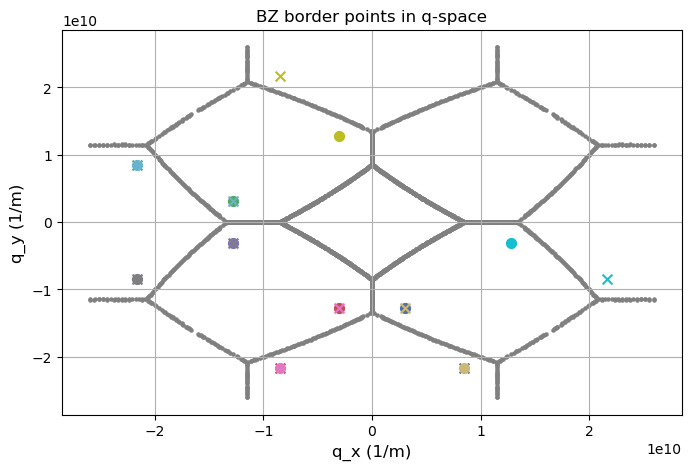

In [41]:
N_best = 20
k_neighbors = 5
best_matches = find_pairs(data_s, data_as, N_best=N_best, k_neighbors=k_neighbors)

colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b3", "#ccb974",
          "#64b5cd", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
          "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
          "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#ff7f0e",
]

plt.figure(figsize=(8, 5))
plt.scatter(bz_border['qx'], bz_border['qy'], s=5, color='grey')
for (match_ind, match) in enumerate(best_matches[:10]):
    plt.scatter(match['q_s'][0], match['q_s'][1], s=50, color=colors[match_ind], marker='o', label='Stokes')
    plt.scatter(match['q_as'][0], match['q_as'][1], s=50, color=colors[match_ind], marker='x', label='anti-Stokes')
plt.xlabel('q_x (1/m)', fontsize='large')
plt.ylabel('q_y (1/m)', fontsize='large')
plt.title('BZ border points in q-space', fontsize='large')
plt.grid(True)
plt.show()

In [48]:
best_match = best_matches[0]
# get_interaction_constant(q, branch_num, channel, crystal_orientation, crystal_lattice, phonon_band_structure, B_arr)
gS_q0 = get_interaction_constant(q=best_match['q_s'], branch_num=branch_num, channel='s', crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure, B_arr=B_arr)
gAS_q0 = get_interaction_constant(q=best_match['q_as'], branch_num=branch_num, channel='as', crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure, B_arr=B_arr)

abs(gS_q0) * T_int / hbar, \
abs(gAS_q0) * T_int / hbar

prefactor = 2.338584121027307e-38
atomic_sum = (2.5690062870908815e-08+6.811257600174651e-08j)
phase_integral ** 0.5 = 3.935616572173231e+21
prefactor = 2.338570735284868e-38
atomic_sum = (-1.2217999353489413e-08+8.359978191726927e-08j)
phase_integral ** 0.5 = 3.951084523394102e+21


(0.001905991538499279, 0.0022207881011286224)

In [ ]:
reciprocal_density = crystal_volume / (2.0 * np.pi) ** 3


6.090703497436761e+21

In [36]:
q = photon_momentum_loss(theta_val=np.pi, phi_val=0.0, channel='s', branch_num=branch_num,
                         crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)

q_BZ, lmn = reduce_to_1stBZ_withRotation(q, crystal_orientation, crystal_lattice)
q_BZ, lmn

(array([ 4.10702080e-01,  4.10702080e-01, -2.70076859e-16]), (4, 4, 0))

In [27]:
theta_s = best_matches[0]['theta_s']
phi_s = best_matches[0]['phi_s']
q_s = best_matches[0]['q_s'] 

theta_as = best_matches[0]['theta_as']
phi_as = best_matches[0]['phi_as']
q_as = best_matches[0]['q_as']

print(q_s)
print(np.linalg.norm(k_in) * np.array([-np.sin(theta_s) * np.cos(phi_s), -np.sin(theta_s) * np.sin(phi_s), 1.0 - np.cos(theta_s)]))
print()
print(q_as)
print(np.linalg.norm(k_in) * np.array([-np.sin(theta_as) * np.cos(phi_as), -np.sin(theta_as) * np.sin(phi_as), 1.0 - np.cos(theta_as)]))

[-2.23827701e+10 -8.86196559e+09  9.52718632e+10]
[-2.23828970e+10 -8.86201585e+09  9.52721161e+10]

[ 1.09513214e+10 -2.81182143e+09  1.00077911e+11]
[ 1.09512592e+10 -2.81180547e+09  1.00077630e+11]


In [ ]:
mesh = [100, 100, 100]

omegas, dos = phonon_band_structure.get_phonon_dos(mesh)

plt.plot(omegas, dos)
plt.show()

np.sum(dos) * (omegas[1] - omegas[0]), \
np.average(dos) * (omegas[-1] - omegas[0])

In [ ]:
theta = 0.731
phi = 0.239
channel = 's'

g_s_list = []
for branch_num in range(6):
    q = photon_momentum_loss(theta, phi, channel, branch_num, phonon_band_structure, crystal_orientation, crystal_lattice)
    g_s = get_interaction_constant(q, branch_num, channel, crystal_orientation, crystal_lattice, phonon_band_structure)
    g_s_list.append(g_s)
g_s_list

In [ ]:
r_s_list = [g_s * T_int / hbar for g_s in g_s_list]
r_s_list

In [ ]:
val = bose_einstein_distr(omega=2.0 * np.pi * 1.0e+12 * 40, 
                          temperature=1860.0
                          )
print(val)

In [ ]:
def get_prefactor():
    """
    prefactor = np.sqrt(photon_number_density) / (2.0 * np.pi) ** 1.5 * \
                2.0 * np.pi * hbar * c * r_e / np.sqrt(np.linalg.norm(k_in) * np.linalg.norm(k_out))
    """
    prefactor = np.sqrt(photon_number_density) / (2.0 * np.pi) ** 1.5
    prefactor *= 2.0 * np.pi * hbar * c * r_e / np.sqrt(np.linalg.norm(k_in) ** 2)    # approximation, in general should be sqrt(k_in * k_out), but for small phonon frequencies, |k_out| ≈ |k_in|
    return prefactor


def get_atomic_sum(q, q_BZ, branch_num, crystal_lattice, crystal_orientation, phonon_band_structure):
    atomic_sum = 0.0
    for atom in range(len(crystal_lattice.symbols)):
        atomic_ff = atomic_form_factor(q, crystal_lattice.symbols[atom])
        dwf = 0.0   # fix later
        phase_factor = np.exp(-1.0j * q @ (crystal_orientation.rotation_matrix @ crystal_lattice.positions[atom]))

        freq_phonon, eigvec = phonon_band_structure.get_frequencies_and_eigvecs(q_BZ, branch_num)
        omega_phonon = freq_phonon * 2.0 * np.pi * 1.0e+12
        eigvec = eigvec[3*atom: 3*atom+3]
        
        atomic_mass = crystal_lattice.atomic_masses_kg[atom]

        to_add = atomic_ff * np.exp(-dwf) * phase_factor 
        to_add *= np.sqrt(hbar / 2.0 / prim_cell_number / atomic_mass / omega_phonon)
        to_add *= q @ (crystal_orientation.rotation_matrix @ eigvec)
        atomic_sum += to_add
    
    return atomic_sum


def safe_ratio(Ni, delta):
    small = np.abs(delta) < 1e-10
    out = np.empty_like(delta)
    out[small] = Ni
    out[~small] = np.sin(Ni * delta[~small] / 2) / np.sin(delta[~small] / 2)
    return out


def get_phase_integral(q, N, T_int, channel, omega_phonon, crystal_orientation, crystal_lattice, rng=20.0, grid_size=201):
    """
    let q = k_in - k_out
    integrate over k_out the following expression:
    \int d^3 k_out (sin(N_1 * q \cdot a_1 / 2) / (q \cdot a_1 / 2) * 
                    sin(N_2 * q \cdot a_2 / 2) / (q \cdot a_2 / 2) * 
                    sin(N_3 * q \cdot a_3 / 2) / (q \cdot a_3 / 2) * 
                    sin(T_int * (c * |k_in| - c * |k_out| -+ omega_phonon) / 2) / ((c * |k_in| - c * |k_out| -+ omega_phonon) / 2))^2
    (- for Stokes, + for anti-Stokes)
    """
    a = crystal_lattice.lattice

    k0 = k_in - q
    print(f'{a = }')
    print(f'{np.linalg.norm(a, axis=1).max() = }')
    dk = rng * np.pi / N.max() / np.linalg.norm(a, axis=1).max()

    kx = k0[0] + np.linspace(-dk, dk, grid_size)
    ky = k0[1] + np.linspace(-dk, dk, grid_size)
    kz = k0[2] + np.linspace(-dk, dk, grid_size)

    dx = kx[1] - kx[0]
    dy = ky[1] - ky[0]
    dz = kz[1] - kz[0]

    # Mesh
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K_out = np.stack([KX, KY, KZ], axis=-1)

    # Spatial mismatch
    delta_k = k_in - K_out - q

    # print(f'correct this part - I forgot to rotate the lattice vectors !!!')
    d1 = np.tensordot(delta_k, crystal_orientation.rotation_matrix @ a[0], axes=([3], [0]))
    d2 = np.tensordot(delta_k, crystal_orientation.rotation_matrix @ a[1], axes=([3], [0]))
    d3 = np.tensordot(delta_k, crystal_orientation.rotation_matrix @ a[2], axes=([3], [0]))

    spatial = (safe_ratio(N[0], d1) * safe_ratio(N[1], d2) * safe_ratio(N[2], d3))
    # Frequency mismatch
    k_out_norm = np.linalg.norm(K_out, axis=3)
    k_in_norm = np.linalg.norm(k_in)

    if channel == "s":
        omega_diff = c * (k_in_norm - k_out_norm) - omega_phonon
    elif channel == "as":
        omega_diff = c * (k_in_norm - k_out_norm) + omega_phonon
    else:
        raise ValueError('incorrect value of the channel parameter')
    
    small = np.abs(omega_diff) < 1e-12
    time = np.empty_like(omega_diff)
    time[small] = T_int
    time[~small] = np.sin(T_int * omega_diff[~small] / 2) / (omega_diff[~small] / 2)

    integrand = (spatial * time) ** 2
    phase_integral = np.sum(integrand) * dx * dy * dz
    return phase_integral


def get_interaction_constant(q, branch_num, channel, N, crystal_lattice, crystal_orientation, phonon_band_structure):
    if channel.lower() == 's':
        q_BZ, lmn = reduce_to_1stBZ_withRotation(q, crystal_orientation, crystal_lattice)
    elif channel.lower() == 'as':
        q_BZ, lmn = reduce_to_1stBZ_withRotation(-q, crystal_orientation, crystal_lattice)
    else:
        raise ValueError('incorrect value of the channel parameter')
    
    prefactor = get_prefactor()
    atomic_sum = get_atomic_sum(q, branch_num, crystal_lattice, crystal_orientation, phonon_band_structure)
    phase_integral = get_phase_integral(q, N, T_int, channel, omega_phonon=phonon_band_structure.get_frequency(q, branch_num) * 2.
    interaction_constant = prefactor * atomic_sum
    return interaction_constant


In [ ]:
theta = 0.731
phi = 0.239
branch_num = 5
q_s = photon_momentum_loss(theta, phi, channel='s', branch_num=branch_num, 
                           crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)
print(f'{q_s = }')

q_BZ_s, lmn_s = reduce_to_1stBZ_withRotation(q_s, crystal_orientation, crystal_lattice)
omega_phonon = phonon_band_structure.get_frequency(q_BZ_s, branch_num) * 2.0 * np.pi * 1.0e+12
print(f'{q_BZ_s = }')
print(f'{lmn_s = }')
print(f'{omega_phonon = }')

N = np.array([10_000, 10_000, 10_000])

T_int = 1.0e-18
phase_int_s = get_phase_integral(q_s, N, T_int, 's', omega_phonon, crystal_orientation, crystal_lattice, rng=20.0, grid_size=121)

phase_int_s, \
8.0 * np.pi ** 3 * N.prod() / np.linalg.det(crystal_lattice.lattice) * T_int ** 2


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from itertools import product
from phonopy import load

material = 'diamond'
yaml_filename = '../VASP_data/diamond/phonopy_disp.yaml'
fc_filename = '../VASP_data/diamond/FORCE_CONSTANTS'


material = 'silicon'
yaml_filename = '../VASP_data/silicon/phonopy_disp.yaml'
fc_filename = '../VASP_data/silicon/FORCE_CONSTANTS'



crystal_lattice = CrystalLattice(material=material)

# cubic crystal 10 um x 10 um x 10 um
Lx = 10.0e-6    
Ly = 10.0e-6    
Lz = 10.0e-6  

phonopy_model = load(phonopy_yaml=yaml_filename, 
                     force_constants_filename=fc_filename, 
                     calculator='vasp'
                    )
print('phonopy model loaded')
phonon_band_structure = PhononBandStructure(phonopy_model=phonopy_model)

alpha, beta, gamma = 0.0, 0.0, 0.0
crystal_orientation = CrystalOrientation(alpha, beta, gamma)

pulse_duration = 30.0e-15    # 30 fs
photon_number = 1.0e+12      # number of photons in the pulse
pulse_width = 10.0e-6        # 10 microns - in transversave direction


hbar = 1.05457e-34  # reduced Planck constant
c = 299_792_458.0   # speed of light
r_e = 2.81794e-15   # classical electron radius
kB = 1.38065e-23    # Boltzmann constant

E_in_ev = 10_000.0
omega_in = E_in_ev * 1.60218e-19 / hbar
k_in = np.array([0, 0, omega_in / c])

T_int = min(pulse_duration, Lz / c)
print(f'{T_int = } s')


  

crystal_volume = Lx * Ly * Lz
print(f'{crystal_lattice.lattice_constant = } m')


aaaaaa




theta_grid = np.linspace(0.001, 0.9, num=1_000)
# phi_grid = np.linspace(0.0, 2.0 * np.pi, num=500)
phi_grid = np.linspace(0.0, np.pi / 2, num=1)[:-1]
phi_grid = np.hstack((phi_grid, phi_grid + np.pi / 2.0, phi_grid + np.pi, phi_grid + 3.0 * np.pi / 2))



branch_num = 5

bz_border = get_bz_border(theta_grid, phi_grid, crystal_orientation, crystal_lattice, phonon_band_structure, eps=1.0e-3)

data_s, data_as = get_sas_data(theta_grid, phi_grid, crystal_orientation, crystal_lattice, phonon_band_structure, branch_num)

matches = find_pairs(data_s, data_as, N_best=10, k_neighbors=5)


colors = ['teal', 'crimson', 'orange', 'purple', 'olive', 'navy', 'cyan', 'magenta', 'brown', 'lime']

plt.scatter(bz_border['qx'], bz_border['qy'], s=5, color='grey')
for (i, match) in enumerate(matches[:10]):
    plt.scatter(match['q_s'][0], match['q_s'][1], color=colors[i], marker='o')
    plt.scatter(match['q_as'][0], match['q_as'][1], color=colors[i], marker='x')
plt.show()

In [ ]:
matches = find_pairs(data_s, data_as, N_best=200, k_neighbors=5)
Qx_s = np.array([match['q_s'][0] for match in matches])
Qy_s = np.array([match['q_s'][1] for match in matches])
Qx_as = np.array([match['q_as'][0] for match in matches])
Qy_as = np.array([match['q_as'][1] for match in matches])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(bz_border['qx'], bz_border['qy'], s=5, color='grey')
axes[0].scatter(Qx_s, Qy_s, color='red', s=6)
axes[0].set_title('Stokes')
axes[0].set_xlabel('Qx')
axes[0].set_ylabel('Qy')

axes[1].scatter(bz_border['qx'], bz_border['qy'], s=5, color='grey')
axes[1].scatter(Qx_as, Qy_as, color='blue', s=6)
axes[1].set_title('Anti-Stokes')
axes[1].set_xlabel('Qx')
axes[1].set_ylabel('Qy')

plt.tight_layout()
plt.show()

In [ ]:
[match['distance'] for match in matches[:]]

In [ ]:
### interaction constant calcualtion for the best match
best_match = matches[0]

photon_density = photon_number / (pulse_width ** 2 * c * pulse_duration)

prim_cell_volume = np.linalg.det(crystal_lattice.lattice)
prim_cell_number = (crystal_volume / prim_cell_volume).astype(int)

prim_cell_number = crystal_volume / prim_cell_volume

prefactor = np.sqrt(photon_density) / (2.0 * np.pi) ** 1.5 * 2.0 * np.pi * hbar * c * r_e / T_int / np.sqrt(np.linalg.norm(k_in) ** 2)   # approximation, in general should be sqrt(k_in * k_out), but for small phonon frequencies, k_out ≈ k_in

q_s = best_match['q_s']
# q_BZ_s = best_match['q_BZ']
atomic_sum = 0.0
for atom in range(len(crystal_lattice.symbols)):
    to_add = atomic_form_factor(q_s, crystal_lattice.symbols[atom]) * np.exp(-0.0) * np.exp(-1.0j * q_s @ (crystal_orientation.rotation_matrix @ crystal_lattice.positions[atom]))
    freq_phonon, eigvec = phonon_band_structure.get_frequency_and_eigvec(best_match['q_BZ_s'], branch_num)
    omega_phonon = freq_phonon * 2.0 * np.pi * 1.0e+12
    eigvec = eigvec[3*atom: 3*atom+3]
    atomic_mass = crystal_lattice.atomic_masses_kg[atom]
    to_add *= np.sqrt(hbar / 2.0 / prim_cell_number / atomic_mass / omega_phonon)
    to_add *= q_s @ (crystal_orientation.rotation_matrix @ eigvec)
    atomic_sum += to_add

print(f'{prefactor = }')
print(f'{atomic_sum = }')

coh_int = 8.0 * np.pi ** 3 * prim_cell_number / prim_cell_volume

r = prefactor * atomic_sum * np.sqrt(coh_int) * T_int ** 2 / hbar
r

In [ ]:
theta = np.pi * 3.0 / 4.0
phi = 0.0

q_s = photon_momentum_loss(theta, phi, channel='s', branch_num=branch_num,
                           crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)
q_as = photon_momentum_loss(theta, phi, channel='as', branch_num=branch_num,
                            crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)

q_BZ_s, lmn_s = reduce_to_1stBZ_withRotation(q_s, crystal_orientation, crystal_lattice)
q_BZ_as, lmn_as = reduce_to_1stBZ_withRotation(-q_as, crystal_orientation, crystal_lattice)

lmn_s, lmn_as

In [ ]:
plt.scatter(bz_border['qx'], bz_border['qy'], s=5, color='grey')

colors = ['teal', 'crimson', 'orange', 'purple', 'olive', 'navy', 'cyan', 'magenta', 'brown', 'lime']
for (i, match) in enumerate(matches):
    plt.scatter(match['q_s'][0], match['q_s'][1], color=colors[i], marker='o')
    plt.scatter(match['q_as'][0], match['q_as'][1], color=colors[i], marker='x')
plt.show()

In [ ]:
match = matches[0]
theta_s = match['theta_s']
phi_s = match['phi_s']
theta_as = match['theta_as']
phi_as = match['phi_as']

q_s = match['q_s']
q_as = match['q_as']

print(f'{q_s = }')
print(f'{q_as = }')

print(f'{theta_s = }')
print(f'{np.arccos((k_in - q_s)[2] / np.linalg.norm(k_in - q_s)) = }')
print()
print(f'{phi_s = }')
print(f'{np.arctan2((k_in - q_s)[1], (k_in - q_s)[0]) = }')
print()
print()

print(f'{theta_as = }')
print(f'{np.arccos((k_in - q_as)[2] / np.linalg.norm(k_in - q_as)) = }')
print()
print(f'{phi_as = }')
print(f'{np.arctan2((k_in - q_as)[1], (k_in - q_as)[0]) = }')
print('===================================')



match = matches[2]
theta_s = match['theta_s']
phi_s = match['phi_s']
theta_as = match['theta_as']
phi_as = match['phi_as']

q_s = match['q_s']
q_as = match['q_as']

print(f'{q_s = }')
print(f'{q_as = }')

print(f'{theta_s = }')
print(f'{np.arccos((k_in - q_s)[2] / np.linalg.norm(k_in - q_s)) = }')
print()
print(f'{phi_s = }')
print(f'{np.arctan2((k_in - q_s)[1], (k_in - q_s)[0]) = }')
print()
print()

print(f'{theta_as = }')
print(f'{np.arccos((k_in - q_as)[2] / np.linalg.norm(k_in - q_as)) = }')
print()
print(f'{phi_as = }')
print(f'{np.arctan2((k_in - q_as)[1], (k_in - q_as)[0]) = }')

In [ ]:
matches[0]['q_BZ_s'], matches[0]['q_BZ_as'],\
matches[1]['q_BZ_s'], matches[1]['q_BZ_as']

In [ ]:
theta = 0.731
phi = 0.239

branch_num = 5
channel = 'as'

q = photon_momentum_loss(theta, phi, channel=channel, branch_num=branch_num,
                        crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure)
print(f'{q = } m^-1')

q_BZ, (l, m, n) = reduce_to_1stBZ_withRotation(q, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice)
print(f'{q_BZ = } (reciprocal lattice basis)')
print(f'{l, m, n = }')

omega_phonon = phonon_band_structure.get_frequency(q_vec=q_BZ, branch_num=branch_num) * 2.0 * np.pi * 1.0e+12

k_out = k_in - crystal_orientation.rotation_matrix @ ((q_BZ + np.array([l, m, n])) @ crystal_lattice.rec_lattice)

k_in, \
k_in - q, \
k_out, \
np.linalg.norm(k_in) - np.linalg.norm(k_out), \
omega_phonon / c

In [ ]:
qq = crystal_orientation.rotation_matrix @ ((q_BZ + np.array([l, m, n])) @ crystal_lattice.rec_lattice)
k_in, \
k_in - qq, \
np.linalg.norm(k_in) - np.linalg.norm(k_in - qq), \
omega_phonon / c

In [ ]:
k_out = k_in - qq

np.arccos(k_out[2] / np.linalg.norm(k_out)), \
np.arctan2(k_out[1], k_out[0])

In [ ]:
q, qq

In [ ]:
phonopy_model.run_qpoints([0.1, 0.0, 0.0])
phonopy_model.qpoints.frequencies


In [ ]:


print(f'omega_in = {omega_in:.2e} rad/s')
print(f'{k_in = }')



alpha, beta, gamma = 0.0, 0.0, 0.0
crystal_orientation = CrystalOrientation(alpha, beta, gamma)
crystal_orientation.rotation_matrix



material = 'diamond'
phonopy_model = load('../VASP_data/diamond/phonopy_disp.yaml', 
                     force_constants_filename='../VASP_data/diamond/FORCE_CONSTANTS', 
                     calculator='vasp'
                    )
print('phonopy model loaded')

crystal_lattice = CrystalLattice(material='diamond')
print(f'{crystal_lattice.rec_lattice = }')
print(f'{crystal_lattice.positions = }')



phonon_band_structure = PhononBandStructure(phonopy_model)
phonon_band_structure.load_bandstructure_from_mp(mp_id='mp-66')
phonon_band_structure.mp_VS_vasp_comparison()
phonon_band_structure.forget_mp_data()
phonon_band_structure.check_eigvecs_symmetry(crystal_lattice.rec_lattice)



theta_grid = np.linspace(0.01, 1.0, num=800)
phi_grid = np.linspace(0.01, 2.0 * np.pi, num=1_000)
bz_border = get_bz_border(theta_grid, phi_grid, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice)

plt.figure(figsize=(8, 5))
plt.scatter(bz_border['qx'], bz_border['qy'], s=10, color='grey')
plt.xlabel('qx (1/m)', fontsize='large')
plt.ylabel('qy (1/m)', fontsize='large')
plt.show()



branch_num = 5
# data_s, data_as = get_sas_data(theta_grid, phi_grid, rotation_matrix=crystal_orientation.rotation_matrix, rec_lattice=crystal_lattice.rec_lattice, phonon_band_structure=phonon_band_structure, branch_num=5)
data_s, data_as = get_sas_data(theta_grid, phi_grid, crystal_orientation=crystal_orientation, crystal_lattice=crystal_lattice, phonon_band_structure=phonon_band_structure, branch_num=branch_num)
data_s



matches = find_pairs(data_s, data_as, N_best=1_200, k_neighbors=5)
matches


q_s_arr = np.array([match['q_s'] for match in matches])
q_as_arr = np.array([match['q_as'] for match in matches])



plt.figure(figsize=(8, 5))
plt.scatter(bz_border['qx'], bz_border['qy'], s=10, color='lightgray', label='BZ border')
plt.scatter(q_s_arr[:, 0], q_s_arr[:, 1], s=2, color='red', label='Stokes')
# plt.scatter(q_as_arr[:, 0], q_as_arr[:, 1], s=2, color='blue', label='anti-Stokes')
plt.xlabel('qx (1/m)', fontsize='large')
plt.ylabel('qy (1/m)', fontsize='large')
plt.legend()
plt.show()



In [ ]:
matches

In [ ]:
    
# def get_interaction_contsant(q_BZ, lmn, branch_num, channel, crystal_lattice, crystal_orientation, phonon_band_structure):
#     # prefactor calculation
#     prefactor = np.sqrt(photon_number) / (2.0 * np.pi) ** 1.5
#     prefactor *= 2.0 * np.pi * hbar * c * r_e / t / np.sqrt(np.linalg.norm(k_in) ** 2)    # approximation, in general should be sqrt(k_in * k_out), but for small phonon frequencies, k_out ≈ k_in
    
#     if channel.lower() == 's':
#         q = crystal_orientation.rotation_matrix @ ((q_BZ + np.array(lmn)) @ crystal_lattice.rec_lattice)
#     elif channel.lower() == 'as':
#         q = -crystal_orientation.rotation_matrix @ ((q_BZ + np.array(lmn)) @ crystal_lattice.rec_lattice)
#     else:
#         raise ValueError('incorrect value of the channel parameter')

#     # atomic sum calculation
#     atomic_sum = 0.0
#     for atom in range(len(crystal_lattice.symbols)):
#         atomic_ff = atomic_form_factor(q, crystal_lattice.symbols[atom])
#         dwf = 0.0   # fox later
#         phase_factor = np.exp(-1.0j * q @ (crystal_orientation.rotation_matrix @ crystal_lattice.positions[atom]))

#         # omega_phonon = phonon_band_structure.get_frequency(q_BZ, branch_num) * 2.0 * np.pi * 1.0e+12
#         freq_phonon, eigvec = phonon_band_structure.get_frequencies_and_eigvecs(q_BZ, branch_num)
#         omega_phonon = freq_phonon * 2.0 * np.pi * 1.0e+12
#         eigvec = eigvec[3*atom: 3*atom+3]
#         print(f'{eigvec.shape = }')
        
        
#         atomic_mass = crystal_lattice.atomic_masses_kg[atom]

#         to_add = atomic_ff * np.exp(-dwf) * phase_factor 
#         to_add *= np.sqrt(hbar / 2.0 / prim_cell_number / atomic_mass / omega_phonon)
#         to_add *= q @ (crystal_orientation.rotation_matrix @ eigvec)
#         atomic_sum += to_add
    
#     # intergal calculation
#     rng = 20.0
#     grid_size = 201
#     k0 = k_in - q
#     dk = rng * np.pi / N.max() / aa

#     kx = k0[0] + np.linspace(-dk, dk, grid_size)
#     ky = k0[1] + np.linspace(-dk, dk, grid_size)
#     kz = k0[2] + np.linspace(-dk, dk, grid_size)

#     dx = kx[1] - kx[0]
#     dy = ky[1] - ky[0]
#     dz = kz[1] - kz[0]

#     # Mesh
#     KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
#     K_out = np.stack([KX, KY, KZ], axis=-1)

#     # Spatial mismatch
#     delta_k = k_in - K_out - q

#     print(f'correct this part - I forgot to rotate the lattice vectors !!!')
#     d1 = np.tensordot(delta_k, a[0], axes=([3], [0]))
#     d2 = np.tensordot(delta_k, a[1], axes=([3], [0]))
#     d3 = np.tensordot(delta_k, a[2], axes=([3], [0]))
    
#     spatial = (safe_ratio(N[0], d1) * safe_ratio(N[1], d2) * safe_ratio(N[2], d3))
#     # Frequency mismatch
#     k_out_norm = np.linalg.norm(K_out, axis=3)
#     k_in_norm = np.linalg.norm(k_in)

#     if channel == "stokes":
#         omega_diff = light_speed * (k_in_norm - k_out_norm) - omega_phonon
#     else:
#         omega_diff = light_speed * (k_in_norm - k_out_norm) + omega_phonon

#     # print(f'{np.abs(omega_diff).min() = }')

#     small = np.abs(omega_diff) < 1e-12
#     time = np.empty_like(omega_diff)
#     time[small] = T_int
#     time[~small] = np.sin(T_int * omega_diff[~small] / 2) / (
#         omega_diff[~small] / 2
#     )

#     integrand = (spatial * time) ** 2
#     coh_int = np.sum(integrand) * dx * dy * dz

#     interaction_constant = prefactor * atomic_sum * coh_int ** 0.5
#     return interaction_constant